A Python notebook to check specific unique entity ratio (UER) per type between two datasets.

## Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import math
from collections import Counter
from EXPERIMENTS.evaluate_gold import load_and_merge_gold_data
from dataset_processing import generate_consistent_label_map, CLIRENER_LABELS_V1, calculate_advanced_metrics
from datasets import load_dataset, concatenate_datasets, DatasetDict


#### Helper functions

In [2]:

def get_filtered_dataset_for_type(dataset, target_type, bio_label_list):
    """
    Creates a copy of the dataset where only the target_type 
    retains its BIO tags; all other entities are masked to 'O'.
    """
    filtered_data = []
    # Identify which IDs in the bio_label_list belong to our target_type
    target_ids = [i for i, name in enumerate(bio_label_list) 
                  if name == f"B-{target_type}" or name == f"I-{target_type}"]
    
    for row in dataset:
        new_tags = [tag if tag in target_ids else 0 for tag in row['ner_tags']]
        filtered_data.append({
            'tokens': row['tokens'],
            'ner_tags': new_tags
        })
    return filtered_data

#### Data

In [3]:



# --- 2. Setup and Loading ---
DATA_ID_1 = "P0L3/CliReNER_v_1_1_28_GOLD"
DATA_ID_2 = "P0L3/CliReNER_v_1_1_28_SILVER"

print(f"--- Loading and Merging GOLD Dataset: {DATA_ID_2} ---")
ds = load_dataset(DATA_ID_2)
silver_test_test = ds["test"]
# actual_types: ['Ecosystem', 'Location', ...]
# bio_labels: ['O', 'B-Ecosystem', 'I-Ecosystem', ...]
actual_types = CLIRENER_LABELS_V1
bio_labels = list(generate_consistent_label_map(CLIRENER_LABELS_V1))

data_1 = load_and_merge_gold_data(DATA_ID_1)
data_2 = load_and_merge_gold_data(DATA_ID_2)

# Using the test splits as requested
gold_test = data_1[0]["test"]
silver_test = data_2[0]["test"]

--- Loading and Merging GOLD Dataset: P0L3/CliReNER_v_1_1_28_SILVER ---
--- Loading and Merging GOLD Dataset: P0L3/CliReNER_v_1_1_28_GOLD ---
Merged ['train', 'validation', 'test'] into a single dataset of size: 192
--- Loading and Merging GOLD Dataset: P0L3/CliReNER_v_1_1_28_SILVER ---
Merged ['train', 'validation', 'test'] into a single dataset of size: 1027


In [32]:
d = get_filtered_dataset_for_type(silver_test_test, "Asset", bio_labels)

In [33]:
for row in d:
    if sum(row["ner_tags"]) > 0:
        # print(row)
        for i, token in enumerate(row["tokens"]):
            if row["ner_tags"][i] != 0:
                print(token, end=" ")
        print()

harvested timber 
renewable resources 
funds health 
housing 
water resources 


## Calc

In [35]:
print(gold_metrics)
print(silver_metrics)

{'Total Tokens': 9715, 'Total Entities': 45, 'Saturation (%)': 0.46320123520329387, 'Entity TTR (0-1)': 0.8666666666666667, 'Avg Span Len': 1.8666666666666667, 'Long Spans (>4t) %': 6.666666666666667, 'Clumping (Adj) %': 4.444444444444445, 'Class Entropy (0-1)': 0.0}
{'Total Tokens': 32268, 'Total Entities': 62, 'Saturation (%)': 0.19214082062724683, 'Entity TTR (0-1)': 0.9032258064516129, 'Avg Span Len': 2.1451612903225805, 'Long Spans (>4t) %': 6.451612903225806, 'Clumping (Adj) %': 1.6129032258064515, 'Class Entropy (0-1)': 0.0}


In [ ]:
# --- 3. Systematic Execution ---
all_type_results = []

for entity_type in actual_types:
    # Filter datasets to isolate this specific entity type
    gold_filtered = get_filtered_dataset_for_type(gold_test, entity_type, bio_labels)
    silver_filtered = get_filtered_dataset_for_type(silver_test, entity_type, bio_labels)
    silver_test_filtered = get_filtered_dataset_for_type(silver_test_test, entity_type, bio_labels)
    
    # Run your advanced metrics function
    gold_metrics = calculate_advanced_metrics(gold_filtered, bio_labels)
    silver_metrics = calculate_advanced_metrics(silver_filtered, bio_labels)
    silver_test_metrics = calculate_advanced_metrics(silver_test_filtered, bio_labels)
    
    if gold_metrics and silver_metrics and silver_test_metrics:
        # We also need to calculate the "Novelty Gap" manually 
        # because the function looks at datasets in isolation.
        
        def get_vocab(dataset_split, target_type, label_names):
            # Helper to get the set of unique lowercased strings for overlap check
            vocab = set()
            for row in dataset_split:
                tokens, tags = row['tokens'], row['ner_tags']
                for i, tid in enumerate(tags):
                    if label_names[tid] == f"B-{target_type}":
                        j = i + 1
                        while j < len(tags) and label_names[tags[j]] == f"I-{target_type}":
                            j += 1
                        vocab.add(" ".join(tokens[i:j]).lower())
            return vocab

        g_vocab = get_vocab(gold_test, entity_type, bio_labels)
        s_vocab = get_vocab(silver_test, entity_type, bio_labels)
        
        overlap = len(g_vocab.intersection(s_vocab))
        novelty_rate = (1 - (overlap / len(g_vocab))) * 100 if g_vocab else 0
        all_type_results.append({
            "Type": entity_type,
            "Gold_Count": gold_metrics["Total Entities"],
            "Silver_Count": silver_metrics["Total Entities"],
            "Silver_Count_Test": silver_test_metrics["Total Entities"],
            "Gold_UER": round(gold_metrics["Entity TTR (0-1)"], 4),
            "Silver_UER": round(silver_metrics["Entity TTR (0-1)"], 4),
            "UER_Diff": round(gold_metrics["Entity TTR (0-1)"] - silver_metrics["Entity TTR (0-1)"], 4),
            "Novelty_Rate (%)": round(novelty_rate, 2),
            "Silver_Avg_Len": round(silver_metrics["Avg Span Len"], 2),
            "Gold_Avg_Len": round(gold_metrics["Avg Span Len"], 2),
            "Avg_Len_Diff": round(silver_metrics["Avg Span Len"], 2) - round(gold_metrics["Avg Span Len"], 2)
            # "Gold_Clumping": round(gold_metrics["Clumping (Adj) %"], 1)
        })

# --- 4. Final Comparison Table ---
df = pd.DataFrame(all_type_results).sort_values("Novelty_Rate (%)", ascending=False)

print("\nCross-Type Comparison using Advanced Metrics")
print("=" * 100)
print(df.to_string(index=False))

# Outlier Detection for Ecosystem
eco_row = df[df["Type"] == "Ecosystem"]
avg_novelty = df["Novelty_Rate (%)"].mean()
avg_uer_diff = df["UER_Diff"].mean()

print("\n--- Diagnostic Findings ---")
if not eco_row.empty:
    e_nov = eco_row["Novelty_Rate (%)"].values[0]
    e_diff = eco_row["UER_Diff"].values[0]
    
    print(f"Ecosystem Novelty Rate: {e_nov}% (Dataset Avg: {avg_novelty:.1f}%)")
    print(f"Ecosystem UER Increase: {e_diff} (Dataset Avg: {avg_uer_diff:.3f})")
    
    if e_nov > avg_novelty + 15:
        print(">> Ecosystem is an outlier in NOVELTY: The model is seeing words it never practiced.")
    if e_diff > 0.1:
        print(">> Ecosystem is an outlier in DIVERSITY: The silver set is too repetitive compared to gold.")


Cross-Type Comparison using Advanced Metrics
                     Type  Gold_Count  Silver_Count  Silver_Count_Test  Gold_UER  Silver_UER  UER_Diff  Novelty_Rate (%)  Silver_Avg_Len  Gold_Avg_Len  Avg_Len_Diff
       Natural Phenomenon          80            86                 19    0.9375      0.9302    0.0073             94.67            1.94          1.85          0.09
                   Policy          73            74                 10    0.9726      0.8784    0.0942             94.37            2.30          2.44         -0.14
      Physical Phenomenon          72           278                 38    0.9444      0.6655    0.2790             91.18            1.88          1.65          0.23
        Physical Artefact          66            52                 10    0.9242      0.8462    0.0781             90.16            1.83          1.55          0.28
     Geographical Feature          57            89                 11    0.9649      0.8876    0.0773             89.09         

In [10]:
def get_silver_gold_gap(target_metric="strict_f1_mean"):
    GOLD_FILE = "EXPERIMENTS/VISUALS/clirener_GOLDagg_aggregated_mean_std.csv" # "clirener_aggregated_mean_std.csv"
    SILVER_FILE = "EXPERIMENTS/VISUALS/clirener_silver_aggregated_mean_std.csv"

    if target_metric not in ["strict_f1_mean", "exact_f1_mean", "partial_f1_mean", "ent_type_f1_mean"]:
        raise ValueError("target metric must be one of [\"strict_f1_mean\", \"exact_f1_mean\", \"partial_f1_mean\", \"ent_type_f1_mean\"].")
    # Choose the metric for gap analysis:
    # options: strict_f1_mean, exact_f1_mean, partial_f1_mean, ent_type_f1_mean
    TARGET_METRIC = target_metric

    # --- Normalization Map (Unifies names between both files) ---
    NAME_NORMALIZATION = {
        "GLiNER_Medium": "GLiNER: Medium v2.5",
        "GLiNER_Small": "GLiNER: Small v2.5",
        "INDUS SDE Base": "INDUS SDE v0.2"
    }


    print(f"Analyzing Generalization Gap: {SILVER_FILE} -> {GOLD_FILE}")
    print(f"Metric: {TARGET_METRIC}\n")

    try:
        df_gold = pd.read_csv(GOLD_FILE)
        df_silver = pd.read_csv(SILVER_FILE)
    except FileNotFoundError as e:
        print(f"Error: {e}")

    # --- STEP 0: UNIFY NAMES ---
    df_gold['model_display_name'] = df_gold['model_display_name'].replace(NAME_NORMALIZATION)
    df_silver['model_display_name'] = df_silver['model_display_name'].replace(NAME_NORMALIZATION)

    # Standardize metrics (ensure silver 'type_f1' matches gold 'ent_type_f1' if necessary)
    # This logic handles the naming discrepancy between the two projects
    if TARGET_METRIC == "ent_type_f1_mean" and "type_f1_mean" in df_silver.columns:
        silver_metric = "type_f1_mean"
    elif TARGET_METRIC == "type_f1_mean" and "ent_type_f1_mean" in df_gold.columns:
        # If user asked for type_f1 but gold uses ent_type_f1
        df_gold = df_gold.rename(columns={"ent_type_f1_mean": "type_f1_mean"})
        silver_metric = TARGET_METRIC
    else:
        silver_metric = TARGET_METRIC

    # --- STEP 1: MERGE DATASETS ---
    # Merge on model and tag to compare directly
    merged = pd.merge(
        df_gold[['model_display_name', 'tag', TARGET_METRIC]],
        df_silver[['model_display_name', 'tag', silver_metric]],
        on=['model_display_name', 'tag'],
        suffixes=('_gold', '_silver')
    )

    if merged.empty:
        print("Error: No overlapping models/tags found between Gold and Silver files.")


    # --- STEP 2: CALCULATE GAPS ---

    # 1. Calculate Absolute Gap
    merged['F1_gap'] = merged[f'{silver_metric}_silver'] - merged[f'{TARGET_METRIC}_gold']


    tag_gap = merged.groupby('tag')[['F1_gap']].mean().reset_index()
    tag_gap = tag_gap.sort_values('F1_gap', ascending=False)

    tag_gap.rename(columns={"tag":"Type"}, inplace=True)
    abs_gap_name = TARGET_METRIC.split("_f1_mean")[0]
    print(abs_gap_name)
    tag_gap.rename(columns={"F1_gap":f"F1_gap_{abs_gap_name}"}, inplace=True)
    return tag_gap

In [11]:
# ["strict_f1_mean", "exact_f1_mean", "partial_f1_mean", "ent_type_f1_mean"]
tag_gap_strict = get_silver_gold_gap()
tag_gap_exact = get_silver_gold_gap("exact_f1_mean")
tag_gap_type = get_silver_gold_gap("ent_type_f1_mean")

Analyzing Generalization Gap: EXPERIMENTS/VISUALS/clirener_silver_aggregated_mean_std.csv -> EXPERIMENTS/VISUALS/clirener_GOLDagg_aggregated_mean_std.csv
Metric: strict_f1_mean

strict
Analyzing Generalization Gap: EXPERIMENTS/VISUALS/clirener_silver_aggregated_mean_std.csv -> EXPERIMENTS/VISUALS/clirener_GOLDagg_aggregated_mean_std.csv
Metric: exact_f1_mean

exact
Analyzing Generalization Gap: EXPERIMENTS/VISUALS/clirener_silver_aggregated_mean_std.csv -> EXPERIMENTS/VISUALS/clirener_GOLDagg_aggregated_mean_std.csv
Metric: ent_type_f1_mean

ent_type


In [18]:
df_withgap = pd.merge(tag_gap_strict, df, on="Type")
df_withgap = pd.merge(tag_gap_exact, df_withgap, on="Type")
df_withgap = pd.merge(tag_gap_type, df_withgap, on="Type")

In [19]:
df_withgap.sort_values(by="F1_gap_strict", inplace=True, ascending=False)

In [31]:
import pandas as pd

# 1. Sort the DataFrame by F1_gap_strict descending (as discussed)
df_sorted = df_withgap.sort_values(by='F1_gap_strict', ascending=False)

# 2. Rename columns to be compact and paper-friendly
column_mapping = {
    'Type': 'Entity Type',
    'F1_gap_ent_type': r'$\Delta$F1 (Type)',
    'F1_gap_exact': r'$\Delta$F1 (Exact)',
    'F1_gap_strict': r'$\Delta$F1 (Strict)',
    'Gold_Count': 'Gold $N$',
    'Silver_Count': 'Silv. $N$',
    'Silver_Count_Test': 'Silv. Test $N$',
    'Gold_UER': 'Gold UER',
    'Silver_UER': 'Silv. UER',
    'UER_Diff': r'UER $\Delta$',
    'Novelty_Rate (%)': r'Novelty (\%)',
    'Silver_Avg_Len': 'Silv. Len',
    'Gold_Avg_Len': 'Gold Len',
    'Avg_Len_Diff': r'Len $\Delta$'
}
df_latex = df_sorted.rename(columns=column_mapping)

# 3. Define decimal formatting rules
format_dict = {
    r'$\Delta$F1 (Type)': '{:.4f}',
    r'$\Delta$F1 (Exact)': '{:.4f}',
    r'$\Delta$F1 (Strict)': '{:.4f}',
    'Gold UER': '{:.4f}',
    'Silv. UER': '{:.4f}',
    r'UER $\Delta$': '{:.4f}',
    r'Novelty (\%)': '{:.1f}',
    'Silv. Len': '{:.2f}',
    'Gold Len': '{:.2f}',
    r'Len $\Delta$': '{:.2f}'
}

# 4. Generate the LaTeX code
latex_code = (
    df_latex.style
    .format(format_dict)
    .hide(axis='index')  # Hides the row numbers (0, 1, 2...)
    .to_latex(
        column_format='lrrrrrrrrrrrrr',  # 1 left-aligned, 13 right-aligned columns
        hrules=True,                     # Uses \toprule, \midrule, \bottomrule (booktabs)
        environment='table*',            # table* makes it span both columns in ACL template
        position='htbp',                 # Placement preference
        caption=r'\textbf{Comprehensive Analysis of the Silver-to-Gold Generalization Gap.} $\Delta$F1 indicates the strict exact-match F1-score difference ($Silver - Gold$). High-variance gaps align with microscopic Silver test sets ($N<10$), length mismatches, and novel expert annotations.',
        label='tab:f1_generalization_gap'
    )
)

# 5. Inject \resizebox to ensure the 14 columns fit on the page
# (Pandas doesn't natively support \resizebox inside to_latex yet)
latex_code = latex_code.replace(
    '\\begin{tabular}', 
    '\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}'
).replace(
    '\\end{tabular}', 
    '\\end{tabular}%\n}'
)

# Print or save to a .tex file
print(latex_code)

# Optional: write directly to a file to \input{} in your main.tex
# with open('f1_gap_table.tex', 'w') as f:
#     f.write(latex_code)

\begin{table*}[htbp]
\caption{\textbf{Comprehensive Analysis of the Silver-to-Gold Generalization Gap.} $\Delta$F1 indicates the strict exact-match F1-score difference ($Silver - Gold$). High-variance gaps align with microscopic Silver test sets ($N<10$), length mismatches, and novel expert annotations.}
\label{tab:f1_generalization_gap}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Entity Type & $\Delta$F1 (Type) & $\Delta$F1 (Exact) & $\Delta$F1 (Strict) & Gold $N$ & Silv. $N$ & Silv. Test $N$ & Gold UER & Silv. UER & UER $\Delta$ & Novelty (\%) & Silv. Len & Gold Len & Len $\Delta$ \\
\midrule
Meteorological Phenomenon & 0.2805 & 0.0896 & 0.2583 & 81 & 255 & 28 & 0.7284 & 0.4275 & 0.3009 & 83.0 & 1.59 & 1.69 & -0.10 \\
Person & 0.1136 & 0.2171 & 0.2399 & 135 & 191 & 21 & 0.6296 & 0.6545 & -0.0248 & 87.1 & 2.10 & 3.67 & -1.57 \\
Ecosystem & 0.2289 & 0.0936 & 0.2309 & 56 & 89 & 6 & 0.6607 & 0.4494 & 0.2113 & 64.9 & 1.48 & 1.71 & -0.23 \\
Asset & 0.2155 & 0.0635 

Spearman Correlation with Performance Gap (abs_gap):
Gold_Count           0.319190
Gold_Avg_Len         0.260131
Novelty_Rate (%)     0.217843
Silver_Count         0.197754
Silver_Count_Test    0.166598
UER_Diff             0.084291
Silver_Avg_Len       0.048740
Gold_UER            -0.081554
Silver_UER          -0.119869
Avg_Len_Diff        -0.272926
Name: abs_gap_strict, dtype: float64


/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.

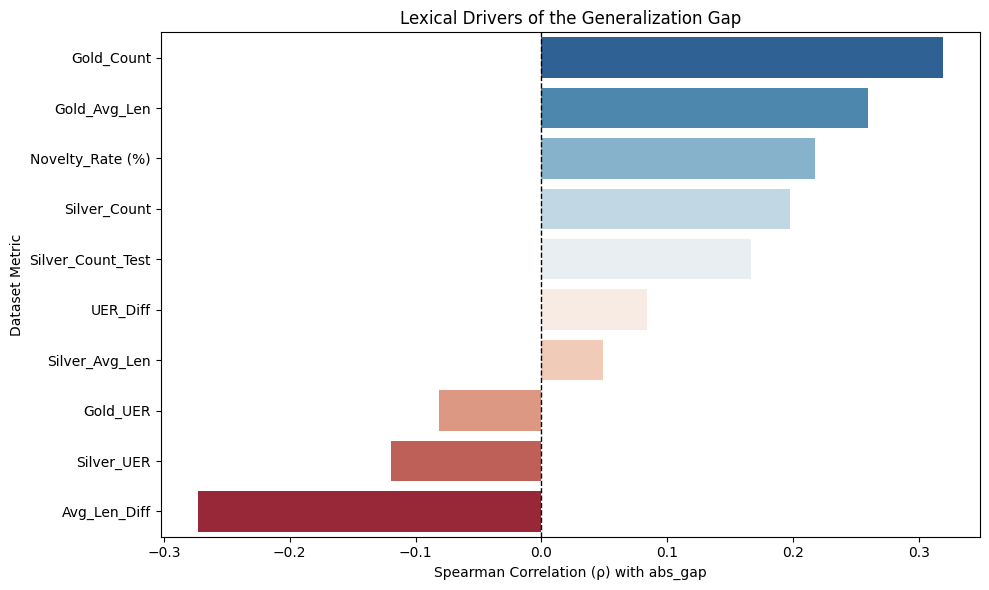

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Spearman correlation, ensuring we only look at numeric columns
# We use abs() on correlations at the end if we want to see 'magnitude', 
# but raw values are better for knowing the 'direction' of the effect.
correlations = df_withgap.corr(method='spearman', numeric_only=True)['abs_gap_strict'].sort_values(ascending=False)

# 2. Remove 'abs_gap' and 'percent_change' from the results so we only see external predictors
throw_out = [r for r in df_withgap.columns if 'abs_gap' in r or 'percent_change' in r]
predictors = correlations.drop(throw_out, errors='ignore')

print("Spearman Correlation with Performance Gap (abs_gap):")
print(predictors)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=predictors.values, y=predictors.index, hue=predictors.index, palette='RdBu_r', legend=False)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Lexical Drivers of the Generalization Gap")
plt.xlabel("Spearman Correlation (ρ) with abs_gap")
plt.ylabel("Dataset Metric")
plt.tight_layout()
plt.show()